In [1]:
import os
import cv2
import imghdr
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights
from PIL import Image

/tmp/ipykernel_18589/524849912.py:3: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [2]:
# ==========================================
# 1. DEPENDENCIES AND SETUP (GPU AYARI)
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Kullanılan Cihaz: {device}")

Kullanılan Cihaz: cuda


In [3]:
# =====================================================
# 2. REMOVE DODGY IMAGES (HATALI RESİMLERİ TEMİZLEME)
# Yalnızca JPEG - JPG - BMP VE PNG
# =====================================================
data_dir = 'drive/MyDrive/imageprocessing/exercises/data'
image_exts = ['jpeg', 'jpg', 'bmp', 'png']

if os.path.exists(data_dir):
    for image_class in os.listdir(data_dir):
        class_path = os.path.join(data_dir, image_class)
        if not os.path.isdir(class_path):
            continue
        for image in os.listdir(class_path):
            image_path = os.path.join(class_path, image)
            try:
                img = cv2.imread(image_path)
                tip = imghdr.what(image_path)
                if tip not in image_exts:
                    print(f'Resim desteklenen uzantılarda değil, siliniyor: {image_path}')
                    os.remove(image_path)
            except Exception as e:
                print(f'Resim açılırken sorun oluştu, siliniyor: {image_path}')
                if os.path.exists(image_path):
                    os.remove(image_path)

In [4]:
# ==========================================
# 3. LOAD DATA & DATA AUGMENTATION
# ==========================================

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = datasets.ImageFolder(root=data_dir, transform=transform)
class_names = dataset.classes
print(f"Tespit Edilen Sınıflar: {class_names}")
print(f"Sınıf İndeksleri: {dataset.class_to_idx}")

Tespit Edilen Sınıflar: ['dips', 'squat']
Sınıf İndeksleri: {'dips': 0, 'squat': 1}


In [5]:
# ============================================================
# 4. SPLIT DATA (VERİ BÖLME)
# %70 eğitim (train) - %10 test - %20 geçerleme (validation)
# ============================================================
train_size = int(0.7 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_data, val_data, test_data = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16, shuffle=False)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)

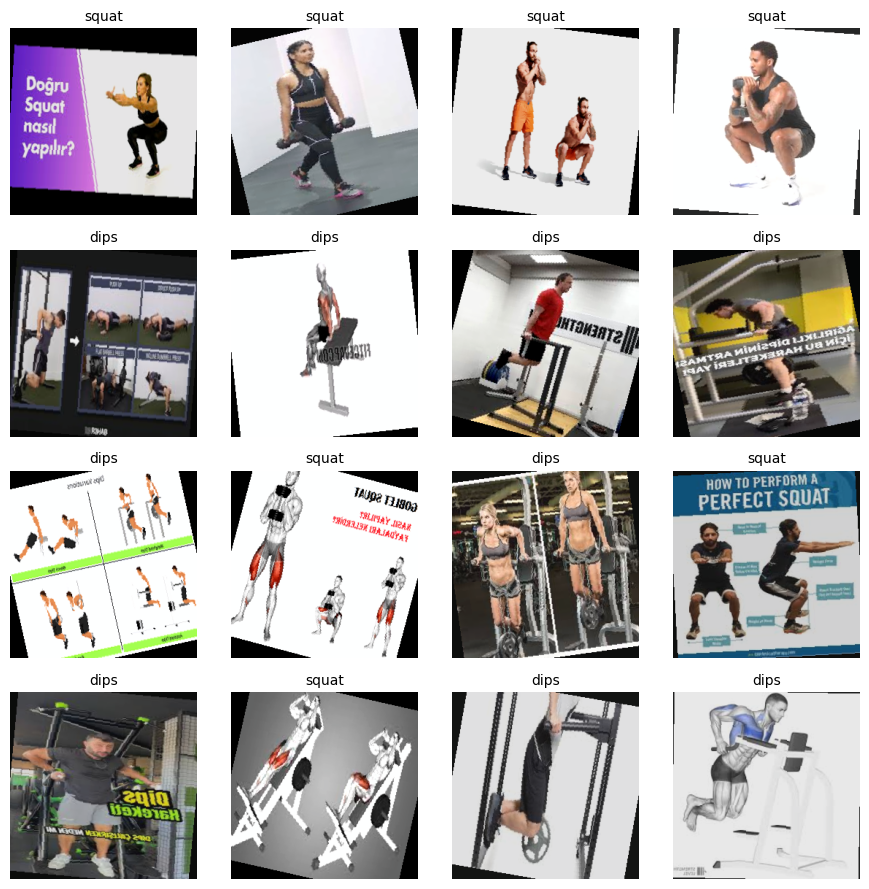

In [6]:
# ==========================================
# 4.5. VISUALIZE RANDOM SAMPLES (RASTGELE ÖRNEKLERİ GÖRSELLEŞTİRME)
# ==========================================
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4

# ImageNet normalizasyonunu geri almak için ters fonksiyonlar
# (Görsellerin düzgün renklerle basılması için gerekli)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]

    # PyTorch boyutunu [C, H, W] -> Matplotlib boyutuna [H, W, C] çeviriyoruz
    img_permuted = img.permute(1, 2, 0).numpy()

    # Normalizasyonu geri çevirip pikselleri [0, 1] arasına kırpıyoruz
    img_permuted = std * img_permuted + mean
    img_permuted = np.clip(img_permuted, 0, 1)

    fig.add_subplot(rows, cols, i)
    plt.imshow(img_permuted)
    plt.title(class_names[label], fontsize=10)
    plt.axis(False)

plt.tight_layout()
plt.show()

In [7]:
# ==================================================================
# 5.  TRANSFER LEARNING (TRANSFER ÖĞRENME)
# ResNet18 kullanıyoruz
# ==================================================================
model = resnet18(weights=ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = True # tüm katmanlar eğitilebilri halde

# ikili sınıf olduğunu belirtiyoruz: çıktı dips ya da squat
num_classes = len(class_names)
num_features = model.fc.in_features
print(f"sınıf sayısı: {num_classes}")

model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features=num_features, out_features=num_classes)
)

model = model.to(device)

sınıf sayısı: 2


In [8]:
# ==========================================
# 6. LOSS - OPTIMIZER
# ==========================================
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)


In [9]:
# ==========================================
# 7. TRAINING LOOP (EĞİTİM DÖNGÜSÜ - ERKEN DURDURMA DAHİL)
# ==========================================
epochs = 20
history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

patience = 6
patience_counter = 0
best_val_loss = float('inf')
best_model_weights = None

print("\nEğitim Başlıyor...")
for epoch in range(epochs):
    # --- Eğitim Aşaması ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        # ÇOK SINIFLI DÜZELTME: targets long() yapıldı ve unsqueeze kaldırıldı [batch_size]
        inputs, targets = inputs.to(device), targets.to(device).long()

        # Gradyanları sıfırla
        optimizer.zero_grad()

        # İleri besleme (Forward pass)
        outputs = model(inputs)
        loss = loss_fn(outputs, targets)

        # Geri besleme (Backward pass)
        loss.backward()

        # Parametreleri güncelle
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        # ÇOK SINIFLI DÜZELTME: En yüksek olasılıklı sınıfın indeksini (tahmini) alıyoruz
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train
    history['loss'].append(epoch_loss)
    history['accuracy'].append(epoch_acc)

    # --- Doğrulama Aşaması ---
    model.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for val_inputs, val_targets in val_loader:
            # ÇOK SINIFLI DÜZELTME: val_targets long() yapıldı ve unsqueeze kaldırıldı
            val_inputs, val_targets = val_inputs.to(device), val_targets.to(device).long()

            val_outputs = model(val_inputs)
            val_loss = loss_fn(val_outputs, val_targets)

            val_running_loss += val_loss.item() * val_inputs.size(0)

            # ÇOK SINIFLI DÜZELTME: Doğrulama için en yüksek olasılıklı sınıfın indeksi
            _, val_preds = torch.max(val_outputs, 1)
            correct_val += (val_preds == val_targets).sum().item()
            total_val += val_targets.size(0)

    epoch_val_loss = val_running_loss / len(val_loader.dataset)
    epoch_val_acc = correct_val / total_val
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f} - Acc: {epoch_acc:.4f} | Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.4f}")

    # --- Early Stopping (Erken Durdurma) Kontrolü ---
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        best_model_weights = copy.deepcopy(model.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n[Early Stopping] {patience} epoch boyunca gelişme olmadı. Eğitim sonlandırıldı!")
            break

# En iyi ağırlıkları modele geri yüklüyoruz
if best_model_weights is not None:
    model.load_state_dict(best_model_weights)
    print("En kararlı model ağırlıkları başarıyla geri yüklendi.")


Eğitim Başlıyor...


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/20] - Loss: 0.5910 - Acc: 0.6767 | Val Loss: 0.3635 - Val Acc: 0.8289
Epoch [2/20] - Loss: 0.2661 - Acc: 0.9060 | Val Loss: 0.3037 - Val Acc: 0.8947
Epoch [3/20] - Loss: 0.1535 - Acc: 0.9549 | Val Loss: 0.1673 - Val Acc: 0.9342
Epoch [4/20] - Loss: 0.0719 - Acc: 0.9812 | Val Loss: 0.1001 - Val Acc: 0.9737
Epoch [5/20] - Loss: 0.0339 - Acc: 0.9925 | Val Loss: 0.0797 - Val Acc: 0.9737
Epoch [6/20] - Loss: 0.0176 - Acc: 1.0000 | Val Loss: 0.0932 - Val Acc: 0.9605
Epoch [7/20] - Loss: 0.0111 - Acc: 1.0000 | Val Loss: 0.0896 - Val Acc: 0.9474
Epoch [8/20] - Loss: 0.0168 - Acc: 0.9962 | Val Loss: 0.0756 - Val Acc: 0.9605
Epoch [9/20] - Loss: 0.0142 - Acc: 1.0000 | Val Loss: 0.0762 - Val Acc: 0.9605
Epoch [10/20] - Loss: 0.0109 - Acc: 1.0000 | Val Loss: 0.0342 - Val Acc: 0.9737
Epoch [11/20] - Loss: 0.0203 - Acc: 0.9887 | Val Loss: 0.0621 - Val Acc: 0.9737
Epoch [12/20] - Loss: 0.0251 - Acc: 0.9925 | Val Loss: 0.0817 - Val Acc: 0.9737
Epoch [13/20] - Loss: 0.0260 - Acc: 0.9925 | Val 

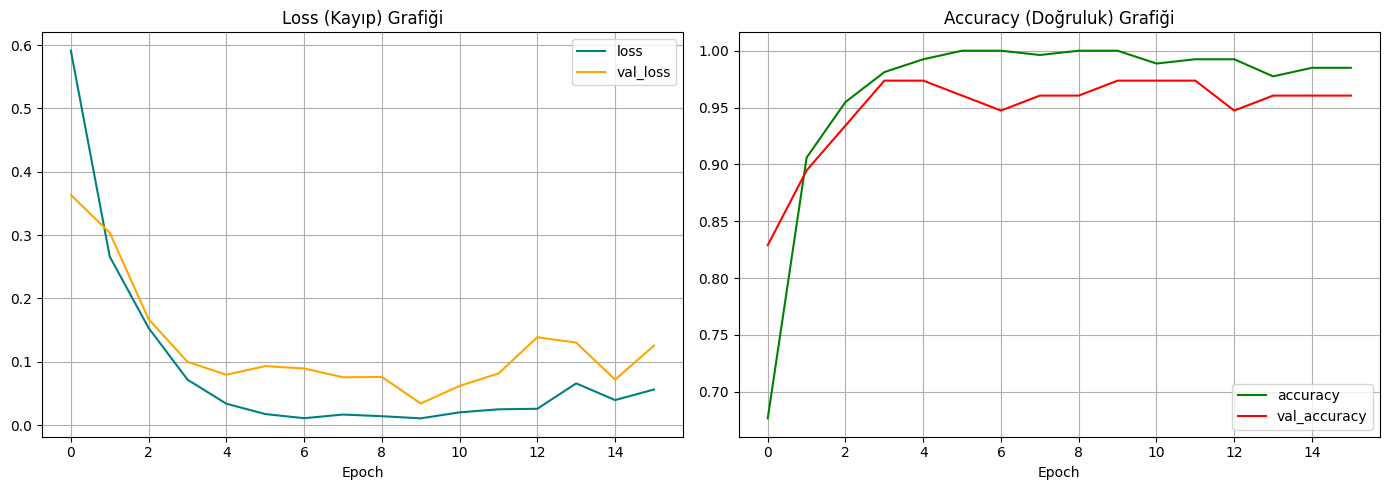

In [10]:
# ==========================================
# 8. PLOT PERFORMANCE (GRAFİKLEME)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['loss'], color='teal', label='loss')
ax1.plot(history['val_loss'], color='orange', label='val_loss')
ax1.set_title("Loss (Kayıp) Grafiği")
ax1.set_xlabel("Epoch")
ax1.legend()
ax1.grid(True)

ax2.plot(history['accuracy'], color='green', label='accuracy')
ax2.plot(history['val_accuracy'], color='red', label='val_accuracy')
ax2.set_title("Accuracy (Doğruluk) Grafiği")
ax2.set_xlabel("Epoch")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [11]:
# ==========================================
# 9. SAVE THE MODEL (MODELİ KAYDETME)
# ==========================================
os.makedirs('models', exist_ok=True)
torch.save(model.state_dict(), os.path.join('models', 'resnet18_classifier.pth'))
print("Model başarıyla 'models/resnet18_classifier.pth' adıyla kaydedildi.")

Model başarıyla 'models/resnet18_classifier.pth' adıyla kaydedildi.


Resim 1 -> Güven: 97.89% | Tahmin: dips
Resim 2 -> Güven: 95.77% | Tahmin: dips
Resim 3 -> Güven: 97.49% | Tahmin: dips
Resim 4 -> Güven: 88.40% | Tahmin: squat


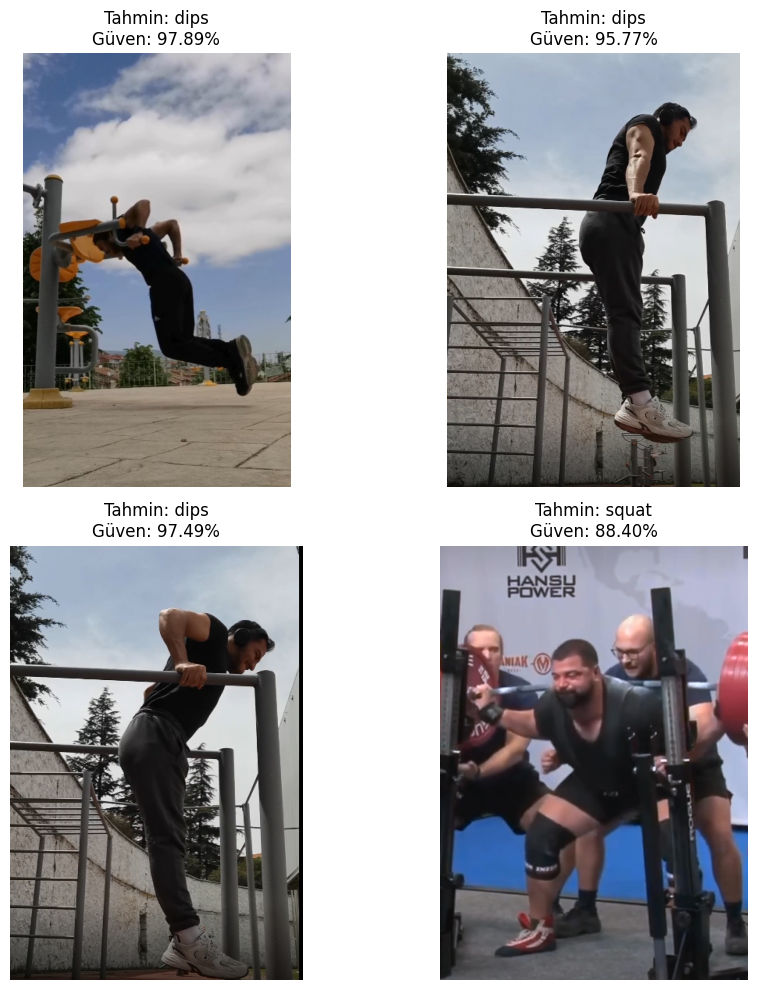

In [12]:
img_paths = [
    'drive/MyDrive/imageprocessing/exercises/my_test/kendi_gorselim.jpeg',
    'drive/MyDrive/imageprocessing/exercises/my_test/kendi_gorselim_2.png',
    'drive/MyDrive/imageprocessing/exercises/my_test/kendi_gorselim_3.png',
    'drive/MyDrive/imageprocessing/exercises/my_test/cenk_kocak.png'
]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.ravel()

predict_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

model.eval()

for i, img_path in enumerate(img_paths):
    try:
        # Görseli oku ve RGB yap
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Ön işleme adımları
        pil_img = Image.fromarray(img)
        input_tensor = predict_transform(pil_img).unsqueeze(0).to(device)

        # Tahmin üretme
        with torch.no_grad():
            raw_output = model(input_tensor)

            # ÇOK SINIFLI DÜZELTME: Sigmoid yerine Softmax ile olasılıkları alıyoruz
            probabilities = torch.softmax(raw_output, dim=1)

            # En yüksek olasılıklı değeri ve onun sınıf indeksini buluyoruz
            confidence, class_idx = torch.max(probabilities, dim=1)

            # Tensor verilerini .item() ile güvenli bir şekilde tekil sayıya çeviriyoruz
            confidence_score = confidence.item()
            predicted_idx = class_idx.item()

        # Dinamik olarak sınıf ismini eşleştiriyoruz
        label_text = class_names[predicted_idx]

        print(f"Resim {i+1} -> Güven: {confidence_score*100:.2f}% | Tahmin: {label_text}")

        # Ekrana çizdirme (Görseli olduğu gibi, bozmadan gösterir)
        axes[i].imshow(img)
        axes[i].set_title(f"Tahmin: {label_text}\nGüven: {confidence_score*100:.2f}%", fontsize=12)
        axes[i].axis('off')

    except Exception as e:
        axes[i].text(0.5, 0.5, "Hata:\nResim işlenemedi", ha='center', va='center', color='red')
        axes[i].axis('off')
        print(f"{img_path} işlenirken hata oluştu: {e}")

plt.tight_layout()
plt.show()

In [14]:
# ==========================================
# 9. VIDEO INFERENCE (İŞLENMİŞ VİDEOYU KAYDETME)
# ==========================================

# Giriş ve çıkış video yolları
video_path = "drive/MyDrive/imageprocessing/exercises/my_test/egilme.mp4"
output_path = "drive/MyDrive/imageprocessing/exercises/my_test/egilme_tahmin.mp4"

cap = cv2.VideoCapture(video_path)

# Video özelliklerini otomatik alıyoruz
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

# Çıktı videosunu yazmak için VideoWriter nesnesi (Colab için en stabil codec MP4V'dir)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

video_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

model.eval()
with torch.no_grad():
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(rgb_frame)

        input_tensor = video_transform(pil_img).unsqueeze(0).to(device)

        # Model tahmini
        outputs = model(input_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        confidence, class_idx = torch.max(probabilities, dim=1)

        class_idx = class_idx.item()
        confidence = confidence.item()

        predicted_class = class_names[class_idx]

        # Yazıyı kareye ekle
        label_text = f"Hareket: {predicted_class} ({confidence*100:.2f}%)"
        cv2.putText(frame, label_text, (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2, cv2.LINE_AA)

        # İşlenmiş kareyi yeni videoya yaz (kaydet)
        out.write(frame)

# Kaynakları serbest bırakma
cap.release()
out.release()
cv2.destroyAllWindows()
print(f"İşlem tamamlandı! Yeni video kaydedildi: {output_path}")

İşlem tamamlandı! Yeni video kaydedildi: drive/MyDrive/imageprocessing/exercises/my_test/egilme_tahmin.mp4


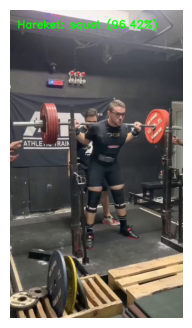

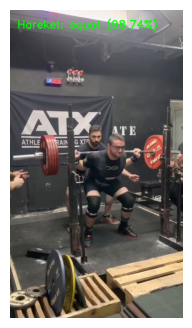

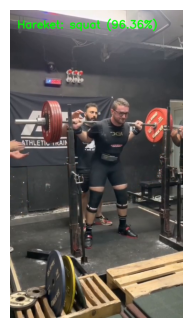

Dinamik çok sınıflı video analizi bitti.


In [15]:
# ==========================================
# 9. VIDEO INFERENCE (KARELERİ EKLEME BASMA)
# ==========================================
import matplotlib.pyplot as plt

video_path = "drive/MyDrive/imageprocessing/exercises/my_test/egilme.mp4"
cap = cv2.VideoCapture(video_path)

video_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

frame_counter = 0

model.eval()
with torch.no_grad():
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(rgb_frame)

        input_tensor = video_transform(pil_img).unsqueeze(0).to(device)

        outputs = model(input_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        confidence, class_idx = torch.max(probabilities, dim=1)

        class_idx = class_idx.item()
        confidence = confidence.item()
        predicted_class = class_names[class_idx]

        label_text = f"Hareket: {predicted_class} ({confidence*100:.2f}%)"
        cv2.putText(frame, label_text, (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2, cv2.LINE_AA)

        # Colab ekranını doldurmaması için her 45 karede bir resmi ekrana basıyoruz
        if frame_counter % 45 == 0:
            plt.figure(figsize=(6, 4))
            # OpenCV'den matplot'a geçerken rengi tekrar düzeltiyoruz
            plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            plt.axis(False)
            plt.show()

        frame_counter += 1

cap.release()
cv2.destroyAllWindows()
print("Dinamik çok sınıflı video analizi bitti.")